In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

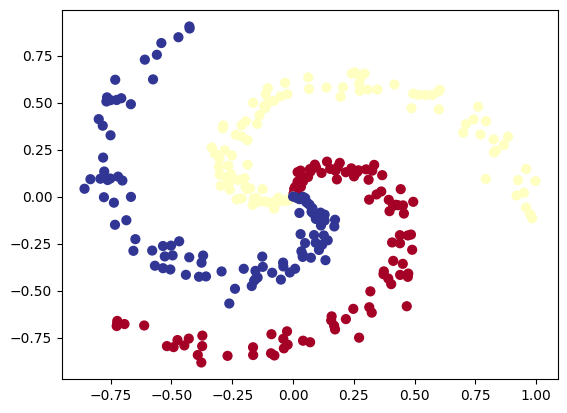

In [3]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
plt.show()

In [4]:
X[:10],y[:10]

(array([[0.        , 0.        ],
        [0.0001288 , 0.01010019],
        [0.00421814, 0.01975674],
        [0.01251715, 0.027597  ],
        [0.00462762, 0.04013816],
        [0.0078066 , 0.04989807],
        [0.03210406, 0.05140451],
        [0.029881  , 0.06408288],
        [0.01837029, 0.0786923 ],
        [0.04134551, 0.08096302]]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=uint8))

In [5]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.long)

In [6]:
X[:20]

tensor([[0.0000e+00, 0.0000e+00],
        [1.2880e-04, 1.0100e-02],
        [4.2181e-03, 1.9757e-02],
        [1.2517e-02, 2.7597e-02],
        [4.6276e-03, 4.0138e-02],
        [7.8066e-03, 4.9898e-02],
        [3.2104e-02, 5.1405e-02],
        [2.9881e-02, 6.4083e-02],
        [1.8370e-02, 7.8692e-02],
        [4.1346e-02, 8.0963e-02],
        [3.0945e-02, 9.6153e-02],
        [3.8235e-02, 1.0433e-01],
        [6.1615e-02, 1.0438e-01],
        [1.8661e-02, 1.2998e-01],
        [3.0954e-02, 1.3798e-01],
        [7.1788e-02, 1.3343e-01],
        [6.9408e-02, 1.4595e-01],
        [1.1701e-01, 1.2568e-01],
        [9.4362e-02, 1.5541e-01],
        [8.9511e-02, 1.6977e-01]])

In [7]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,
                                                 y,
                                                 test_size = 0.2,
                                                 random_state=42)

In [8]:
from torchmetrics import Accuracy

acc_fn = Accuracy(task = "multiclass",num_classes= 4).to(device)
acc_fn

MulticlassAccuracy()

In [9]:
class SpiralModel(nn.Module):

    def __init__(self,input_features,output_features,hidden_units=8):
        
        super().__init__()

        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features , out_features= hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,out_features=output_features),

        )

    def forward(self,x):
        return self.linear_layer_stack(x)


In [10]:
model_0 = SpiralModel(input_features=2,
                      output_features=3).to(device)

model_0

SpiralModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=3, bias=True)
  )
)

In [11]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [12]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.01)

In [13]:
torch.softmax(model_0(X.to(device)),dim = 1).argmin(dim = 1),y

(tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0

In [14]:
X[:20]


tensor([[0.0000e+00, 0.0000e+00],
        [1.2880e-04, 1.0100e-02],
        [4.2181e-03, 1.9757e-02],
        [1.2517e-02, 2.7597e-02],
        [4.6276e-03, 4.0138e-02],
        [7.8066e-03, 4.9898e-02],
        [3.2104e-02, 5.1405e-02],
        [2.9881e-02, 6.4083e-02],
        [1.8370e-02, 7.8692e-02],
        [4.1346e-02, 8.0963e-02],
        [3.0945e-02, 9.6153e-02],
        [3.8235e-02, 1.0433e-01],
        [6.1615e-02, 1.0438e-01],
        [1.8661e-02, 1.2998e-01],
        [3.0954e-02, 1.3798e-01],
        [7.1788e-02, 1.3343e-01],
        [6.9408e-02, 1.4595e-01],
        [1.1701e-01, 1.2568e-01],
        [9.4362e-02, 1.5541e-01],
        [8.9511e-02, 1.6977e-01]])

In [16]:
epochs = 10000

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)


for epoch in range(epochs):

    model_0.train()

    y_pred = model_0(X_train)

    loss = loss_fn(y_pred,y_train)

    acc_train = acc_fn(y_pred.argmax(dim =1),y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 100 == 0 :
        model_0.eval()
        with torch.inference_mode():
            y_preds = model_0(X_test)
            y_prob = y_preds.argmax(dim = 1)
            
            test_loss = loss_fn(y_preds,y_test)

            acc = acc_fn(y_prob,y_test)

            print(f"Epochs: {epoch} | Loss: {loss} | Test Loss: {test_loss} | Acc = {acc}")

Epochs: 0 | Loss: 1.1133097410202026 | Test Loss: 1.1373876333236694 | Acc = 0.2666666805744171
Epochs: 100 | Loss: 1.088000774383545 | Test Loss: 1.1036211252212524 | Acc = 0.2666666805744171
Epochs: 200 | Loss: 1.076154112815857 | Test Loss: 1.0876809358596802 | Acc = 0.2666666805744171
Epochs: 300 | Loss: 1.06715726852417 | Test Loss: 1.0757954120635986 | Acc = 0.36666667461395264
Epochs: 400 | Loss: 1.05872642993927 | Test Loss: 1.065735101699829 | Acc = 0.46666666865348816
Epochs: 500 | Loss: 1.0494214296340942 | Test Loss: 1.0554865598678589 | Acc = 0.4833333194255829
Epochs: 600 | Loss: 1.0387271642684937 | Test Loss: 1.0442359447479248 | Acc = 0.5166666507720947
Epochs: 700 | Loss: 1.0262964963912964 | Test Loss: 1.0316540002822876 | Acc = 0.5166666507720947
Epochs: 800 | Loss: 1.0118272304534912 | Test Loss: 1.0173758268356323 | Acc = 0.5333333611488342
Epochs: 900 | Loss: 0.9950589537620544 | Test Loss: 1.0011824369430542 | Acc = 0.550000011920929
Epochs: 1000 | Loss: 0.97592

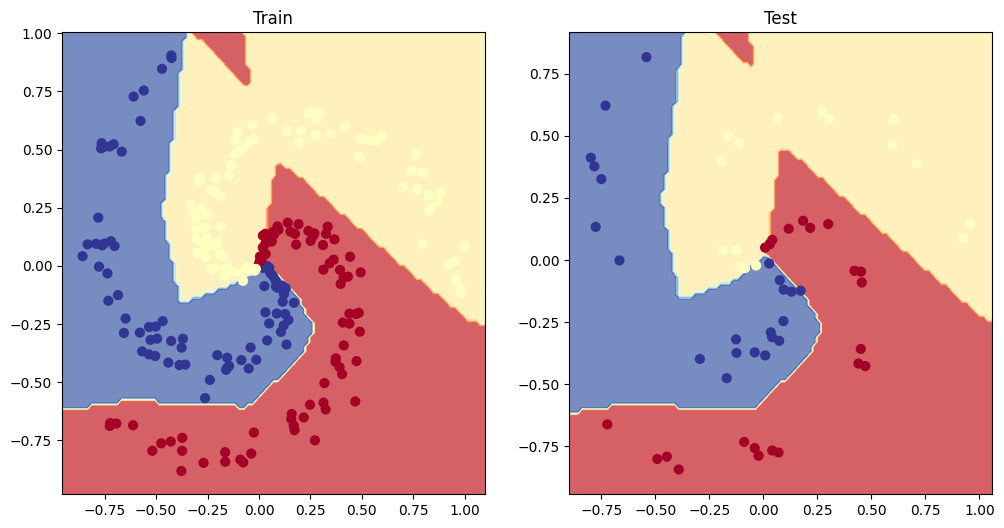

In [17]:
from helper_functions import plot_predictions, plot_decision_boundary
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [19]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True,exist_ok = True)

MODEL_NAME = "MultiClassifier_Model"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj = model_0.state_dict(),f =MODEL_SAVE_PATH)